## Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## Load dataset

In [3]:
file_path = "D:/Code/project_code/Project/data/processed/master_dataset_cleaned.csv"
df = pd.read_csv(file_path)
df

,course_id,course_title,price,level,subject,source_platform,enrollment_id,student_name,student_email,rating_score,completion_rate,enrollment_date,payment_method,has_enrollment
0,1070968,Ultimate Investment Banking Course,200.0,All Levels,Business Finance,Udemy Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1113822,Complete GST Course & Certification - Grow You...,75.0,All Levels,Business Finance,Udemy Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1006314,Financial Modeling for Business Analysts and C...,45.0,Intermediate Level,Business Finance,Udemy Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,95.0,All Levels,Business Finance,Udemy Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,1011058,How To Maximize Your Profits Trading Options,200.0,Intermediate Level,Business Finance,Udemy Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12022,ONLINE166972,Unknown Course,45.0,Unspecified,Unspecified,Online Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
12023,ONLINE914188,Unknown Course,45.0,Unspecified,Unspecified,Online Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
12024,ONLINE654524,Unknown Course,45.0,Unspecified,Unspecified,Online Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
12025,ONLINE136897,Unknown Course,45.0,Unspecified,Unspecified,Online Courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## Xem thông tin tổng quan của dataset

In [4]:
print("kích thước của dataset: ")
print(f"số dòng: {df.shape[0]}")
print(f"số cột: {df.shape[1]}")
print("-"*50)
print("các cột có trong dataset: ")
print(df.columns.tolist())
print("-"*50)
print("kiểu dữ liệu của từng cột trong dataset: ")
print(df.dtypes)

kích thước của dataset: 
số dòng: 12027
số cột: 14
--------------------------------------------------
các cột có trong dataset: 
['course_id', 'course_title', 'price', 'level', 'subject', 'source_platform', 'enrollment_id', 'student_name', 'student_email', 'rating_score', 'completion_rate', 'enrollment_date', 'payment_method', 'has_enrollment']
--------------------------------------------------
kiểu dữ liệu của từng cột trong dataset: 
course_id              str
course_title           str
price              float64
level                  str
subject                str
source_platform        str
enrollment_id          str
student_name           str
student_email          str
rating_score       float64
completion_rate    float64
enrollment_date        str
payment_method         str
has_enrollment       int64
dtype: object


## Xem thống kê mô tả

In [5]:
df.describe()

,price,rating_score,completion_rate,has_enrollment
count,12027.000000,1500.000000,1500.000000,12027.000000
mean,56.406336,3.043667,49.245333,0.124719
std,87.005446,1.173743,29.190316,0.330414
min,0.000000,1.000000,1.000000,0.000000
25%,45.000000,2.000000,24.000000,0.000000
50%,45.000000,3.000000,48.500000,0.000000
75%,45.000000,4.100000,75.000000,0.000000
max,4600.000000,5.000000,100.000000,1.000000


## Xem chủ đề các khóa học (subject)

In [6]:
subjects = df['subject'].value_counts()
print(subjects)

subject
Unspecified                         5273
Web Development                     1286
Business Finance                    1260
Business                             895
Musical Instruments                  735
Graphic Design                       654
Computer Science                     455
Data Science                         448
Health                               264
Information Technology               221
Physical Science and Engineering     150
Arts and Humanities                  120
Language Learning                     86
Social Sciences                       83
Personal Development                  68
Math and Logic                        22
计算机科学                                  1
Ciencia de Datos                       1
Negocios                               1
Ciencias de la Computación             1
Negócios                               1
データサイエンス                               1
Tecnologia da informação               1
Name: count, dtype: int64


## Hiển thị bằng biểu đồ Barchart cho top chủ đề các khóa học (subject)

top 8 chủ đề khóa học xuất hiện nhiều nhất: 
subject
Unspecified            5273
Web Development        1286
Business Finance       1260
Business                895
Musical Instruments     735
Graphic Design          654
Computer Science        455
Data Science            448
Name: count, dtype: int64


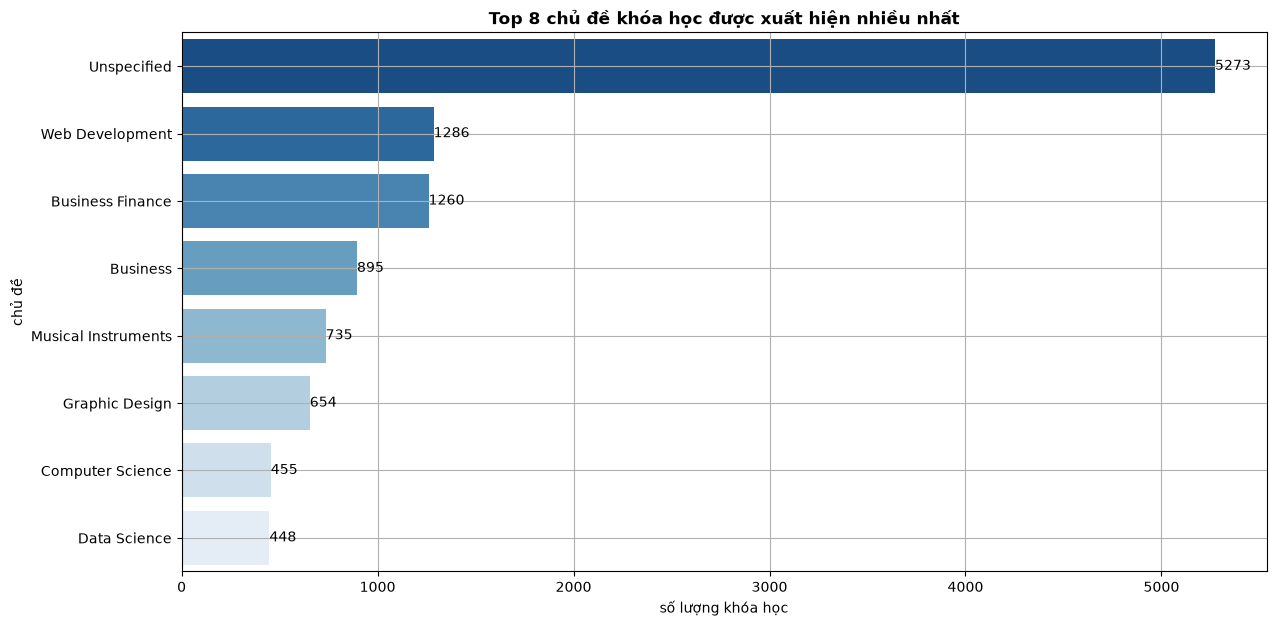

In [7]:
top_subjects = subjects.head(8)
print("top 8 chủ đề khóa học xuất hiện nhiều nhất: ")
print(top_subjects)
fig, axes = plt.subplots(figsize=(14, 7))
ax = sns.barplot(
    x=top_subjects.values,
    y=top_subjects.index,
    hue= top_subjects.index,
    palette='Blues_r',
    legend=False
)
axes.set_title("Top 8 chủ đề khóa học được xuất hiện nhiều nhất", fontsize=12, fontweight='bold')
axes.set_xlabel("số lượng khóa học", fontsize=10)
axes.set_ylabel("chủ đề", fontsize=10)
for container in ax.containers: 
    ax.bar_label(container)
plt.grid()

plt.show()

**Giải thích:**
- **Sự phân hóa nguồn cung**: Nhóm nhãn "Unspecified" chiếm tỷ trọng áp đảo (5.273 khóa học), cho thấy tập dữ liệu thô có lượng lớn bản ghi bị thiếu thông tin phân loại từ nguồn gốc.
- **Lĩnh vực dẫn đầu**: Trong các chủ đề có tên cụ thể, Web Development (1.286) và Business Finance (1.260) chiếm lượng cung lớn nhất, phản ánh xu hướng tập trung mạnh vào hai nhóm kỹ năng công nghệ và tài chính trên thị trường.\
- **Hàm ý cho mô hình**: Tỷ lệ lớn dữ liệu "Unspecified" lưu ý rằng cần có chiến lược xử lý dữ liệu (như gán nhãn thay thế hoặc loại bỏ có chọn lọc) trước khi đưa vào các bước phân tích chuyên sâu và huấn luyện mô hình Machine Learning

## Biểu đồ Pie phân bố mức độ học tập

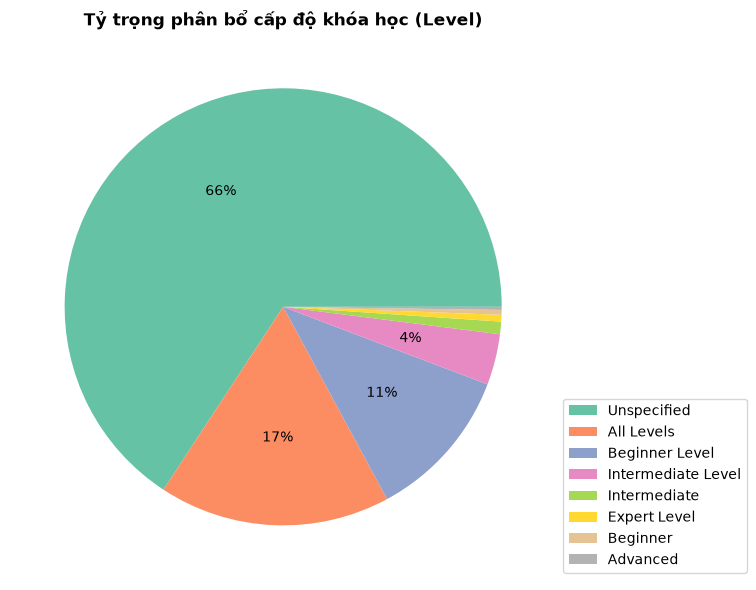

In [47]:
level_counts = df['level'].value_counts()
fig, axes = plt.subplots(figsize=(10, 6))
colors=sns.color_palette('Set2')


plt.pie(
  level_counts.values,
    labels=None,
    colors=colors, 
    autopct=lambda p: f"{p:.0f}%" if p >= 2 else ""
 )
axes.set_title(
    'Tỷ trọng phân bổ cấp độ khóa học (Level)', fontsize=12, fontweight='bold')
axes.set_title(
    'Tỷ trọng phân bổ cấp độ khóa học (Level)',
    fontsize=12,
    fontweight='bold'
)

axes.legend(
    level_counts.index,  
    loc="lower left",
    bbox_to_anchor=(1, 0)
)
plt.tight_layout()
plt.show()

**Giải thích:**
- **Sự thống trị của dữ liệu trống**: Nhóm "Unspecified" chiếm tỷ trọng áp đảo lên tới 66% tổng số lượng khóa học, tiếp theo là "All Levels" (17%) và "Beginner Level" (11%). Điều này phản ánh rõ nét tính đặc thù của dữ liệu thô thu thập được từ thực tế, nơi các thuộc tính phân loại thường bị thiếu sót nghiêm trọng.   
- **Sự phân mảnh nhãn**: Các biến thể phân loại bị tách rời (ví dụ: "Intermediate Level" và "Intermediate", hoặc "Beginner Level" và "Beginner") cho thấy dữ liệu chưa được chuẩn hóa đồng bộ từ bước tiền xử lý.  
- **Hàm ý cho phân tích**: Cần thực hiện các bước làm sạch dữ liệu mạnh mẽ hơn như chuẩn hóa, gộp nhóm các nhãn tương đồng hoặc xử lý các giá trị khuyết thiếu trước khi đưa vào các bước phân tích sâu (Multivariate Analysis) hay huấn luyện mô hình Machine Learning.  


## Phân tích tác động "giá cả" đến trạng thái của các khóa học(price vs Enrollment)

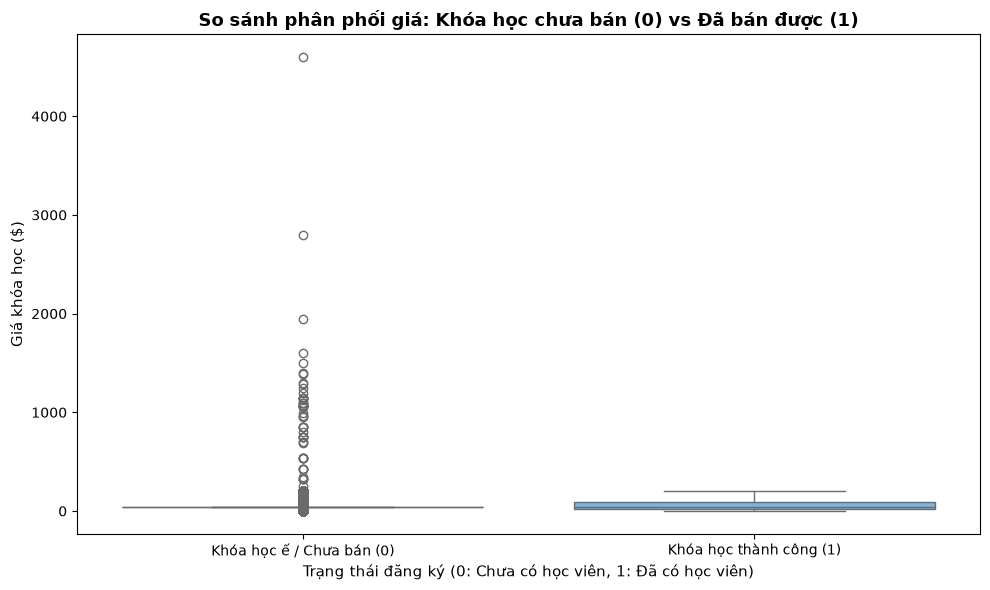

Bảng thống kê mô thả theo trạng thái:
                  count       mean        std  min   25%   50%   75%     max
has_enrollment                                                              
0               10527.0  55.075425  90.015895  0.0  45.0  45.0  45.0  4600.0
1                1500.0  65.746667  61.099356  0.0  20.0  45.0  95.0   200.0


In [46]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='has_enrollment',
    y='price',
    data=df,
    palette=['#ff9999', '#66b3ff'],
    hue='has_enrollment',
    legend=False,
)
plt.title(
    'So sánh phân phối giá: Khóa học chưa bán (0) vs Đã bán được (1)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel(
    'Trạng thái đăng ký (0: Chưa có học viên, 1: Đã có học viên)', fontsize=11
)
plt.ylabel('Giá khóa học ($)', fontsize=11)
plt.xticks([0, 1], ['Khóa học ế / Chưa bán (0)', 'Khóa học thành công (1)'])

plt.tight_layout()
plt.show()
print('Bảng thống kê mô thả theo trạng thái:')
print(df.groupby('has_enrollment')['price'].describe())

**Giải thích:**
- **Sự xuất hiện của Outliers (Giá trị ngoại lai)**: Nhóm khóa học chưa bán (0) tập trung nhiều điểm ngoại lai có mức giá rất cao (lên đến trên 4.000$), trong khi phần lớn dữ liệu tập trung ở mức thấp.   
- **Rào cản giá cả**: Các khóa học thành công (1) có phân phối giá nằm gọn ở phân khúc thấp hơn và ổn định hơn, cho thấy mức giá cao có thể là một trong những rào cản khiến học viên không đăng ký.   
- **Hàm ý cho mô hình**: Cần xem xét xử lý hoặc chuẩn hóa các giá trị ngoại lai về giá (outliers) trước khi đưa vào các thuật toán Machine Learning để tránh làm sai lệch trọng số của mô hình.

## Khảo sát chất lượng (rating & completion rate) của khóa học đã bán

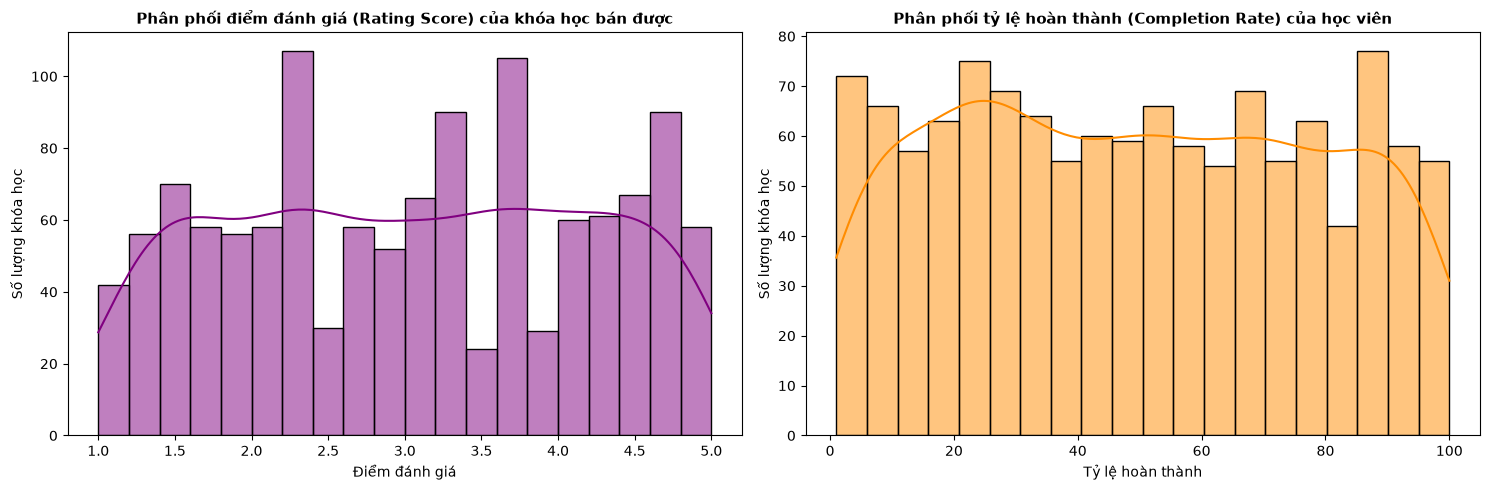

In [42]:
#Mục tiêu: Đánh giá xem các khóa học thực tế có học viên mua thì chất lượng ra sao (chỉ xét trên subset has_enrollment == 1).
# Lọc ra các dòng thực sự có phát sinh đăng ký để phân tích chất lượng
df_sold = df[df['has_enrollment'] == 1].drop_duplicates(subset=['course_id'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Phân phối điểm đánh giá (Rating Score)
sns.histplot(
    ax=axes[0],
    x=df_sold['rating_score'],
    bins=20,
    kde=True,
    color='purple',
)
axes[0].set_title(
    'Phân phối điểm đánh giá (Rating Score) của khóa học bán được',
    fontsize=11,
    fontweight='bold',
)
axes[0].set_xlabel('Điểm đánh giá', fontsize=10)
axes[0].set_ylabel('Số lượng khóa học', fontsize=10)

# 2. Phân phối tỷ lệ hoàn thành (Completion Rate)
sns.histplot(
    ax=axes[1],
    x=df_sold['completion_rate'],
    bins=20,
    kde=True,
    color='darkorange',
)
axes[1].set_title(
    'Phân phối tỷ lệ hoàn thành (Completion Rate) của học viên',
    fontsize=11,
    fontweight='bold',
)
axes[1].set_xlabel('Tỷ lệ hoàn thành', fontsize=10)
axes[1].set_ylabel('Số lượng khóa học', fontsize=10)

plt.tight_layout()
plt.show()

**Giải thích:**
- **Phân phối điểm đánh giá (Rating Score)**: Điểm số của các khóa học bán được trải đều trên nhiều mức khác nhau (có cả các đỉnh ở mức trung bình và cao), cho thấy các khóa học có người đăng ký không giới hạn ở mức tuyệt đối mà bao gồm cả các đánh giá đa dạng từ học viên.   
- **Tỷ lệ hoàn thành (Completion Rate)**: Đồ thị phân phối tương đối đồng đều từ mức thấp đến cao (đường KDE dao động ổn định quanh các khoảng giá trị), phản ánh rằng mức độ hoàn thành khóa học của học viên không tập trung dồn về một cực duy nhất mà phân hóa theo từng đối tượng.   
- **Hàm ý cho mô hình**: Các chỉ số chất lượng học tập (rating, completion) có độ biến thiên rộng, có thể dùng làm các biến đặc trưng tiềm năng để phân loại sâu hơn về mức độ hài lòng của học viên trong các bước phân tích nâng cao.   

## Ma trận tương quan (Correlation heatmap)

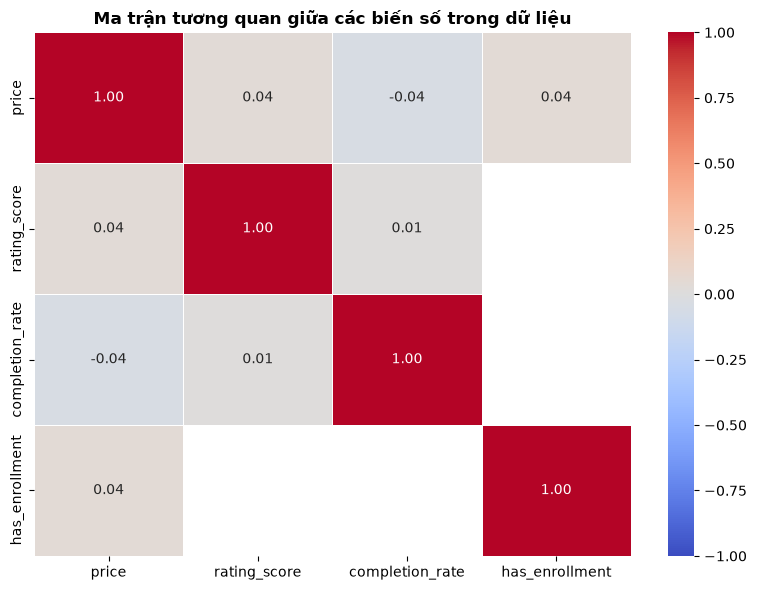

In [43]:
#Mục tiêu: Kiểm tra xem các biến số như giá cả (price), 
#điểm đánh giá (rating_score), tỷ lệ hoàn thành (completion_rate) 
#và trạng thái đăng ký (has_enrollment) có mối liên hệ 
#tuyến tính nào với nhau không.

# Chọn các cột số cần tính tương quan
numeric_cols = ['price', 'rating_score', 'completion_rate', 'has_enrollment']

plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()

# Vẽ heatmap
sns.heatmap(
    corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1
)
plt.title(
    'Ma trận tương quan giữa các biến số trong dữ liệu',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

**Giải thích:**
- **Độ tương quan tuyến tính thấp**: Các hệ số tương quan giữa price, rating_score, completion_rate và biến mục tiêu has_enrollment đều xấp xỉ 0 (ví dụ: price với has_enrollment là 0.04). Điều này cho thấy không có mối quan hệ tuyến tính đơn lẻ mạnh nào giữa các biến số này.   
- **Tính phức tạp của bài toán**: Việc không có tương quan tuyến tính rõ ràng chứng tỏ hành vi đăng ký khóa học của học viên phụ thuộc vào các mối quan hệ phi tuyến tính hoặc sự kết hợp đa chiều của nhiều yếu tố khác nhau (như chủ đề, cấp độ, chiến lược giá tổng hợp).   
- **Hàm ý cho mô hình**: Các mô hình tuyến tính đơn giản (như Linear Regression) sẽ không hiệu quả; do đó cần ưu tiên sử dụng các thuật toán Machine Learning có khả năng bắt tương quan phi tuyến (như Decision Tree, Random Forest) cho giai đoạn dự đoán tiếp theo. 